# Neural Network approach 

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
from tensorflow.keras.utils import plot_model
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU Available: []


## Load and Explore Data

In [2]:
# Load features and targets
X = pd.read_csv(r'C:\Users\ISHAN\ML\DL Project\input_features.csv', header=None)
y = np.loadtxt(r'C:\Users\ISHAN\ML\DL Project\max_stress_list.txt')

# Align lengths if there's a mismatch
n = min(len(X), len(y))
if len(X) != len(y):
    print(f"Warning: features rows ({len(X)}) and targets ({len(y)}) mismatch — trimming to {n} rows")
    X = X.iloc[:n]
    y = y[:n]

X = X.values.astype(np.float32)
y = y.astype(np.float32)

print(f"Features shape: {X.shape}")
print(f"Targets shape: {y.shape}")
print(f"\nFeatures statistics:")
print(f"  Min: {X.min():.6f}, Max: {X.max():.6f}, Mean: {X.mean():.6f}")
print(f"\nTargets statistics:")
print(f"  Min: {y.min():.2e}, Max: {y.max():.2e}, Mean: {y.mean():.2e}")

Features shape: (5000, 226)
Targets shape: (5000,)

Features statistics:
  Min: 0.000200, Max: 0.002000, Mean: 0.001101

Targets statistics:
  Min: 4.41e+06, Max: 4.37e+07, Mean: 9.50e+06


## Data Preprocessing

In [3]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Log-transform targets before standardizing (reduces right-skew, helps regression)
y_train_log = np.log(y_train)
y_test_log  = np.log(y_test)

# Standardize log-transformed labels
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train_log.reshape(-1, 1)).flatten()
y_test  = y_scaler.transform(y_test_log.reshape(-1, 1)).flatten()

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nScaled features (train):")
print(f"  Min: {X_train.min():.4f}, Max: {X_train.max():.4f}, Mean: {X_train.mean():.4f}")
print(f"\nScaled log-targets (train):")
print(f"  Min: {y_train.min():.4f}, Max: {y_train.max():.4f}, Mean: {y_train.mean():.4f}")

Training set: (4000, 226)
Test set: (1000, 226)

Scaled features (train):
  Min: -2.7593, Max: 2.7520, Mean: 0.0000

Scaled log-targets (train):
  Min: -2.1238, Max: 4.7566, Mean: -0.0000


## Build Neural Network Model

In [4]:
# Build the model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(400, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(200, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(100, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(60, activation='relu'),
    layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 400)            │        90,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,021 (781.33 KB)

 Trainable params: 198,621 (775.86 KB)

 Non-trainable params: 1,400 (5.47 KB)

In [5]:
# plot_model(model, show_shapes=True, show_layer_names=False)

## Train the Model

In [6]:
# Define callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=300,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.2226 - mae: 0.8472 - val_loss: 0.7842 - val_mae: 0.6586 - learning_rate: 0.0010
Epoch 2/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6962 - mae: 0.6386 - val_loss: 0.6167 - val_mae: 0.5869 - learning_rate: 0.0010
Epoch 3/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5233 - mae: 0.5560 - val_loss: 0.5136 - val_mae: 0.5380 - learning_rate: 0.0010
Epoch 4/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4071 - mae: 0.4915 - val_loss: 0.4599 - val_mae: 0.4948 - learning_rate: 0.0010
Epoch 5/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3330 - mae: 0.4432 - val_loss: 0.4090 - val_mae: 0.4704 - learning_rate: 0.0010
Epoch 6/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2984 - mae: 0.4218 - val_loss: 0.3908 - val_mae: 0.4591 - learning_rate: 0.0010
Epoch 7/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2602 - mae: 0.3938 - val_loss: 0.3855 - val_mae: 0.4537 - learning_rate: 0.0010
Epoch 8/300
5

## Evaluate Model Performance

In [7]:
# Make predictions on test set
y_pred_scaled = model.predict(X_test).flatten()

# Inverse transform: un-standardize then un-log
y_pred = np.exp(y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten())
y_test_original = np.exp(y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten())

# Calculate metrics
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("=" * 50)
print("MODEL EVALUATION ON TEST SET")
print("=" * 50)
print(f"Mean Squared Error (MSE):   {mse:.4e}")
print(f"Root Mean Squared Error:    {rmse:.4e}")
print(f"Mean Absolute Error (MAE):  {mae:.4e}")
print(f"R² Score:                   {r2:.6f}")
print("=" * 50)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MODEL EVALUATION ON TEST SET
Mean Squared Error (MSE):   4.2593e+12
Root Mean Squared Error:    2.0638e+06
Mean Absolute Error (MAE):  1.1778e+06
R² Score:                   0.679720


## Visualize Training History

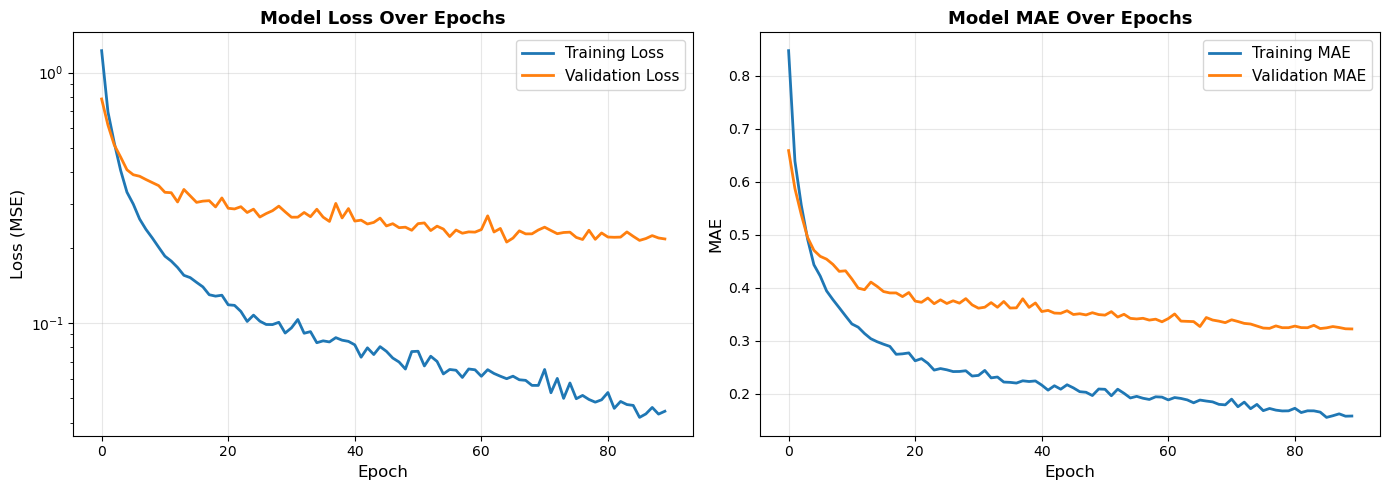

In [8]:
# Plot training and validation loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Model Loss Over Epochs', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Model MAE Over Epochs', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualize Predictions vs Actual

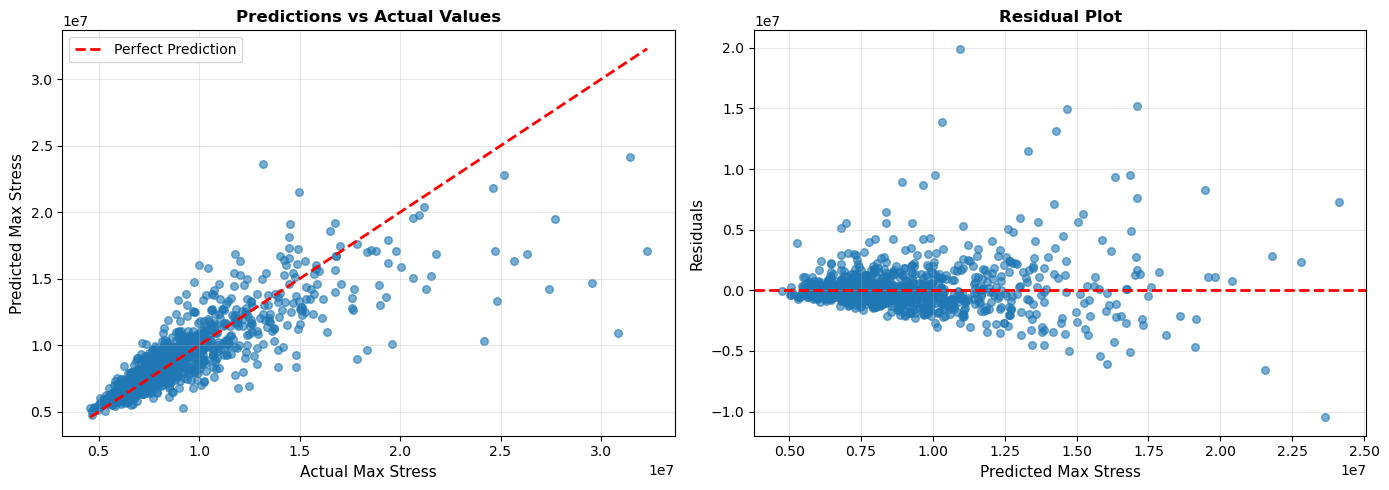

Residuals - Min: -1.0465e+07, Max: 1.9913e+07, Mean: 1.4674e+05


In [9]:
# Create prediction plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Predictions vs Actual
axes[0].scatter(y_test_original, y_pred, alpha=0.6, s=30)
min_val = min(y_test_original.min(), y_pred.min())
max_val = max(y_test_original.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Max Stress', fontsize=11)
axes[0].set_ylabel('Predicted Max Stress', fontsize=11)
axes[0].set_title('Predictions vs Actual Values', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test_original - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Max Stress', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuals - Min: {residuals.min():.4e}, Max: {residuals.max():.4e}, Mean: {residuals.mean():.4e}")


## Save Model and Scaler

In [10]:
import os
import joblib

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the trained model in modern keras format
model.save('models/max_stress_model.keras')
print("✓ Model saved to: models/max_stress_model.keras")

# Save the scalers
joblib.dump(scaler, 'models/scaler.joblib')
print("✓ Feature scaler saved to: models/scaler.joblib")

joblib.dump(y_scaler, 'models/y_scaler.joblib')
print("✓ Label scaler saved to: models/y_scaler.joblib")

print("\nFiles ready for inference!")

✓ Model saved to: models/max_stress_model.keras
✓ Feature scaler saved to: models/scaler.joblib
✓ Label scaler saved to: models/y_scaler.joblib

Files ready for inference!


## Example: Make Predictions on New Data

In [11]:
# Example: Load model and scalers to make predictions on a few test samples
loaded_model = keras.models.load_model('models/max_stress_model.keras')
loaded_scaler = joblib.load('models/scaler.joblib')
loaded_y_scaler = joblib.load('models/y_scaler.joblib')

# Get some test samples (from scaled data)
n_samples = 5
X_sample = X_test[:n_samples]
y_sample_scaled = y_test[:n_samples]

# Inverse transform y_test back to original scale for comparison
y_sample = loaded_y_scaler.inverse_transform(y_sample_scaled.reshape(-1, 1)).flatten()

# Make predictions (on scaled features)
predictions_scaled = loaded_model.predict(X_sample, verbose=0).flatten()

# Inverse transform predictions to original scale
predictions = loaded_y_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()

# Display results
print("Sample Predictions vs Actual Values:")
print("=" * 60)
print(f"{'Sample':<10} {'Actual':<20} {'Predicted':<20} {'Error':<15}")
print("=" * 60)
for i in range(n_samples):
    error = abs(y_sample[i] - predictions[i])
    print(f"{i+1:<10} {y_sample[i]:<20.4e} {predictions[i]:<20.4e} {error:<15.4e}")
print("=" * 60)

Sample Predictions vs Actual Values:
Sample     Actual               Predicted            Error          
1          1.6095e+01           1.6142e+01           4.6251e-02     
2          1.5456e+01           1.5580e+01           1.2386e-01     
3          1.5820e+01           1.5854e+01           3.3436e-02     
4          1.6113e+01           1.5883e+01           2.3028e-01     
5          1.5861e+01           1.5957e+01           9.5416e-02     


## Classify Predictions and Validate Against Labels

In [15]:
# Classify Predictions on TEST DATA ONLY
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

# Define thresholds for classification
p10 = 6256616.91  # 10th Percentile
p25 = 7078345.55  # 25th Percentile
p50 = 8434359.31  # 50th Percentile

# Function to classify predictions into 4 classes
def classify_stress(value):
    """
    Classify stress value into 4 classes based on percentiles:
    0: below 10th percentile
    1: between 10th and 25th percentile
    2: between 25th and 50th percentile
    3: above 50th percentile
    """
    if value < p10:
        return 0
    elif value < p25:
        return 1
    elif value < p50:
        return 2
    else:
        return 3

# Make predictions on TEST SET ONLY (using scaled features)
y_pred_test_scaled = model.predict(X_test, verbose=0).flatten()
y_pred_test = np.exp(y_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten())

# Classify predictions for test set
y_pred_test_classified = np.array([classify_stress(pred) for pred in y_pred_test])

# Load actual classifications for test set
y_actual_all = pd.read_csv(r'C:\Users\ISHAN\ML\DL Project\stress_classifications.csv', header=None).values.flatten()

# Get the test indices (from the original train_test_split)
# We need to reconstruct which indices belong to the test set
# Let's use the y_test from earlier in the notebook which is already the test portion
X_full = pd.read_csv(r'C:\Users\ISHAN\ML\DL Project\input_features.csv', header=None)
y_full = np.loadtxt(r'C:\Users\ISHAN\ML\DL Project\max_stress_list.txt')
n = min(len(X_full), len(y_full))
X_full = X_full.iloc[:n].values
y_full = y_full[:n]

# Re-create the exact test set from earlier
X_train_check, X_test_check, y_train_check, y_test_check, idx_train, idx_test = train_test_split(
    X_full, y_full, np.arange(len(y_full)), test_size=0.2, random_state=42
)

# Get the corresponding actual classifications for test indices
y_test_actual_classified = y_actual_all[idx_test]

print(f"\nTest Set Shape: {X_test.shape}")
print(f"Test Predictions shape: {y_pred_test_classified.shape}")
print(f"Test Actual labels shape: {y_test_actual_classified.shape}")

# Calculate metrics for test set only
accuracy_test = accuracy_score(y_test_actual_classified, y_pred_test_classified)
conf_matrix_test = confusion_matrix(y_test_actual_classified, y_pred_test_classified, labels=[0, 1, 2, 3])
class_report_test = classification_report(y_test_actual_classified, y_pred_test_classified, labels=[0, 1, 2, 3])

print("\n" + "=" * 70)
print("CLASSIFICATION RESULTS - TEST DATA ONLY")
print("=" * 70)
print(f"\nThresholds:")
print(f"  Class 0: predictions < {p10:,.2f}")
print(f"  Class 1: {p10:,.2f} <= predictions < {p25:,.2f}")
print(f"  Class 2: {p25:,.2f} <= predictions < {p50:,.2f}")
print(f"  Class 3: predictions >= {p50:,.2f}")

print(f"\n✓ Accuracy (Test): {accuracy_test:.4f}")
print(f"\nConfusion Matrix (Test):")
print(conf_matrix_test)

print(f"\n{class_report_test}")

# Distribution of predictions vs actual for test set
print("\n" + "=" * 70)
print("CLASS DISTRIBUTION - TEST DATA ONLY")
print("=" * 70)
pred_dist_test = np.bincount(y_pred_test_classified, minlength=4)
actual_dist_test = np.bincount(y_test_actual_classified, minlength=4)

print(f"{'Class':<10} {'Predicted':<15} {'Actual':<15} {'Difference':<15}")
print("-" * 55)
for i in range(4):
    diff = pred_dist_test[i] - actual_dist_test[i]
    print(f"{i:<10} {pred_dist_test[i]:<15} {actual_dist_test[i]:<15} {diff:<15}")


ParserError: Error tokenizing data. C error: out of memory

NameError: name 'conf_matrix_test' is not defined

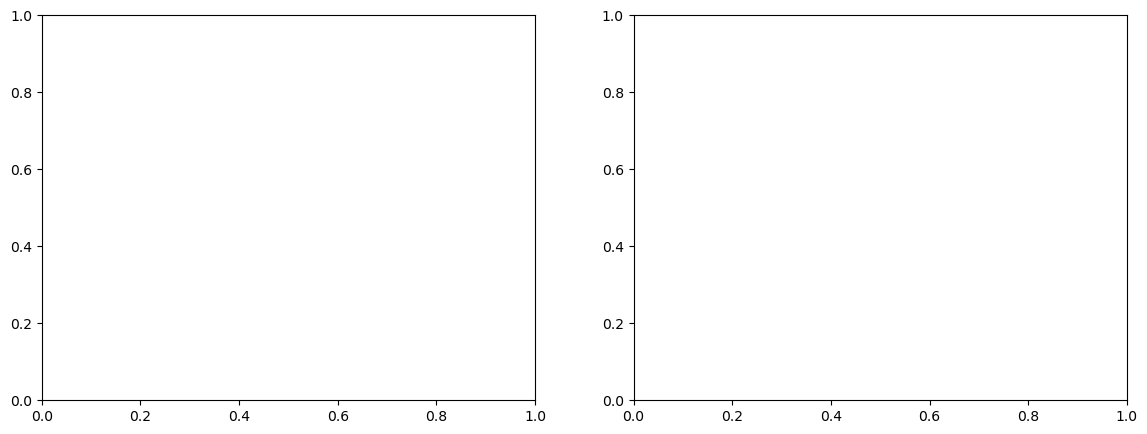

In [16]:
# Visualize Confusion Matrix and Classification Results - TEST DATA ONLY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap (Test Set)
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
            yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('Actual Class', fontsize=12)
axes[0].set_title(f'Confusion Matrix - Test Data (Accuracy: {accuracy_test:.4f})', fontsize=13, fontweight='bold')

# Class distribution comparison (Test Set)
x = np.arange(4)
width = 0.35
axes[1].bar(x - width/2, actual_dist_test, width, label='Actual', alpha=0.8, color='steelblue')
axes[1].bar(x + width/2, pred_dist_test, width, label='Predicted', alpha=0.8, color='coral')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Class Distribution (Test): Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Class 0', 'Class 1', 'Class 2', 'Class 3'])
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Show sample predictions for test data
print("\nSample Classifications from Test Data (first 20 samples):")
print("=" * 90)
print(f"{'Index':<8} {'Predicted Value':<20} {'Predicted Class':<18} {'Actual Class':<15} {'Match':<8}")
print("=" * 90)
for i in range(min(20, len(y_pred_test))):
    match = "✓" if y_pred_test_classified[i] == y_test_actual_classified[i] else "✗"
    print(f"{i:<8} {y_pred_test[i]:<20.2e} {y_pred_test_classified[i]:<18} {y_test_actual_classified[i]:<15} {match:<8}")
print("=" * 90)
